In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("C:\\Users\\User\\OneDrive\\Desktop\\python project\\cleaned_Dataset.csv")

In [19]:

team_total_runs = df.groupby('batting_team')['total_runs'].sum()
team_total_runs = team_total_runs.sort_values(ascending=False)

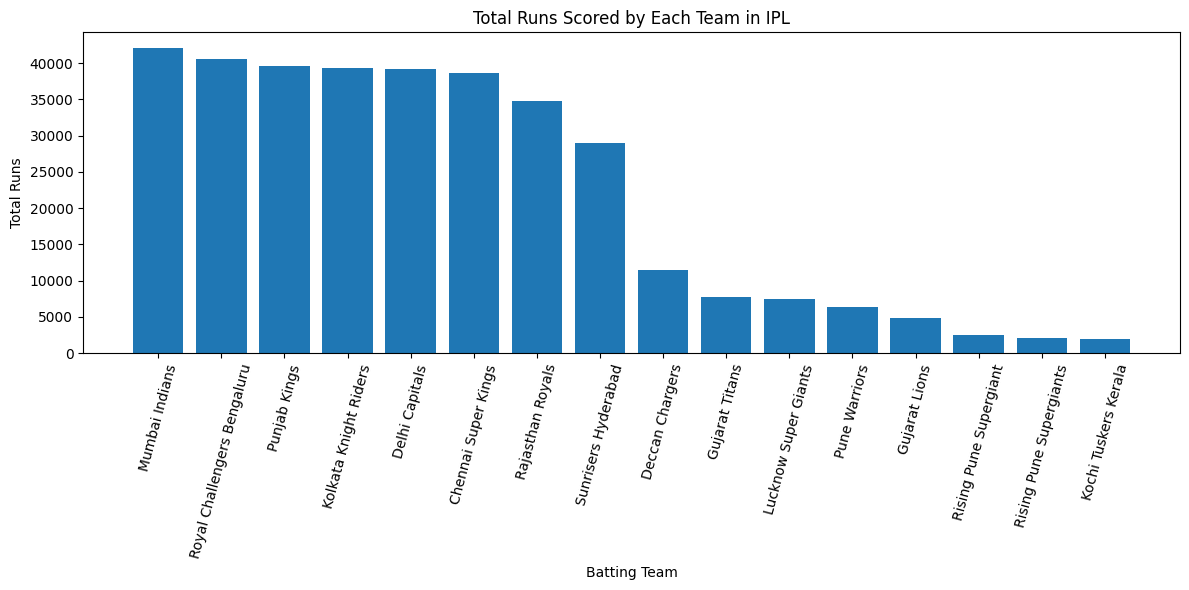

In [20]:
plt.figure(figsize=(12,6))

plt.bar(team_total_runs.index, team_total_runs.values)

plt.title("Total Runs Scored by Each Team in IPL")
plt.xlabel("Batting Team")
plt.ylabel("Total Runs")

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [ ]:

top_batters = df.groupby('batter')['batsman_runs'].sum()
top_batters = top_batters.sort_values(ascending=False)
top_batters = top_batters.head(10)

print(top_batters)

batter
V Kohli           8004
S Dhawan          6769
RG Sharma         6628
DA Warner         6565
SK Raina          5528
MS Dhoni          5243
AB de Villiers    5162
CH Gayle          4965
RV Uthappa        4952
KD Karthik        4842
Name: batsman_runs, dtype: int64


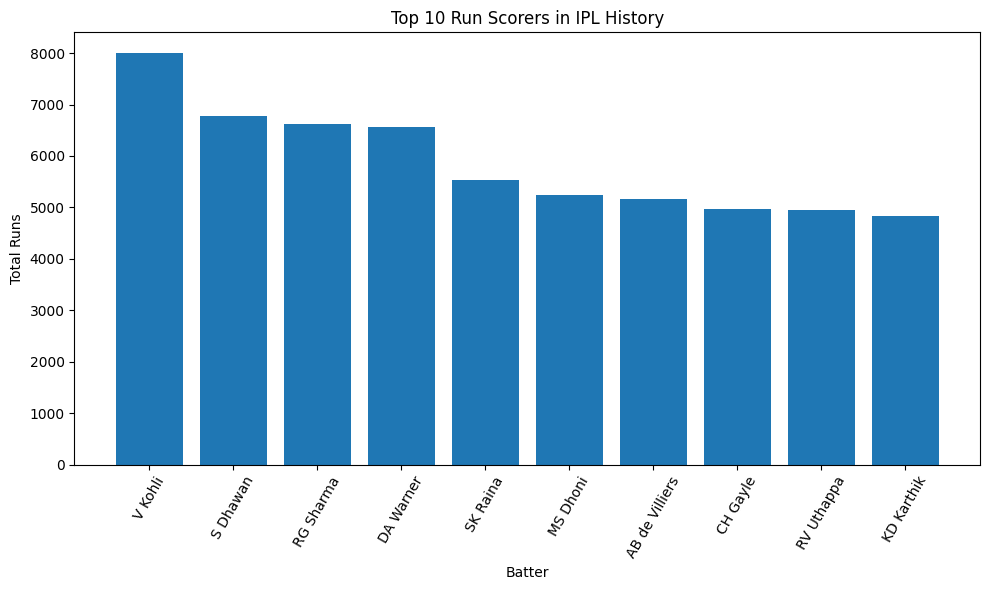

In [23]:
plt.figure(figsize=(10,6))

plt.bar(top_batters.index, top_batters.values)

plt.title("Top 10 Run Scorers in IPL History")
plt.xlabel("Batter")
plt.ylabel("Total Runs")

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [33]:
df['is_dot'] = df['batsman_runs'] == 0
dot_ball = df.groupby('bowling_team').agg(
    total_balls=('is_dot', 'count'),
    dot_balls=('is_dot', 'sum')
)

dot_ball['Dot_Ball_Percent'] = (dot_ball['dot_balls'] / dot_ball['total_balls']) * 100

print(dot_ball)

                             total_balls  dot_balls  Dot_Ball_Percent
bowling_team                                                         
Chennai Super Kings                28572      11503         40.259695
Deccan Chargers                     9039       3805         42.095365
Delhi Capitals                     29920      11768         39.331551
Gujarat Lions                       3540       1252         35.367232
Gujarat Titans                      5301       2081         39.256744
Kochi Tuskers Kerala                1614        713         44.175960
Kolkata Knight Riders              29644      11843         39.950749
Lucknow Super Giants                5226       2061         39.437428
Mumbai Indians                     31477      12779         40.597897
Pune Warriors                       5457       2148         39.362287
Punjab Kings                       29176      11439         39.206882
Rajasthan Royals                   26412      10524         39.845525
Rising Pune Supergia

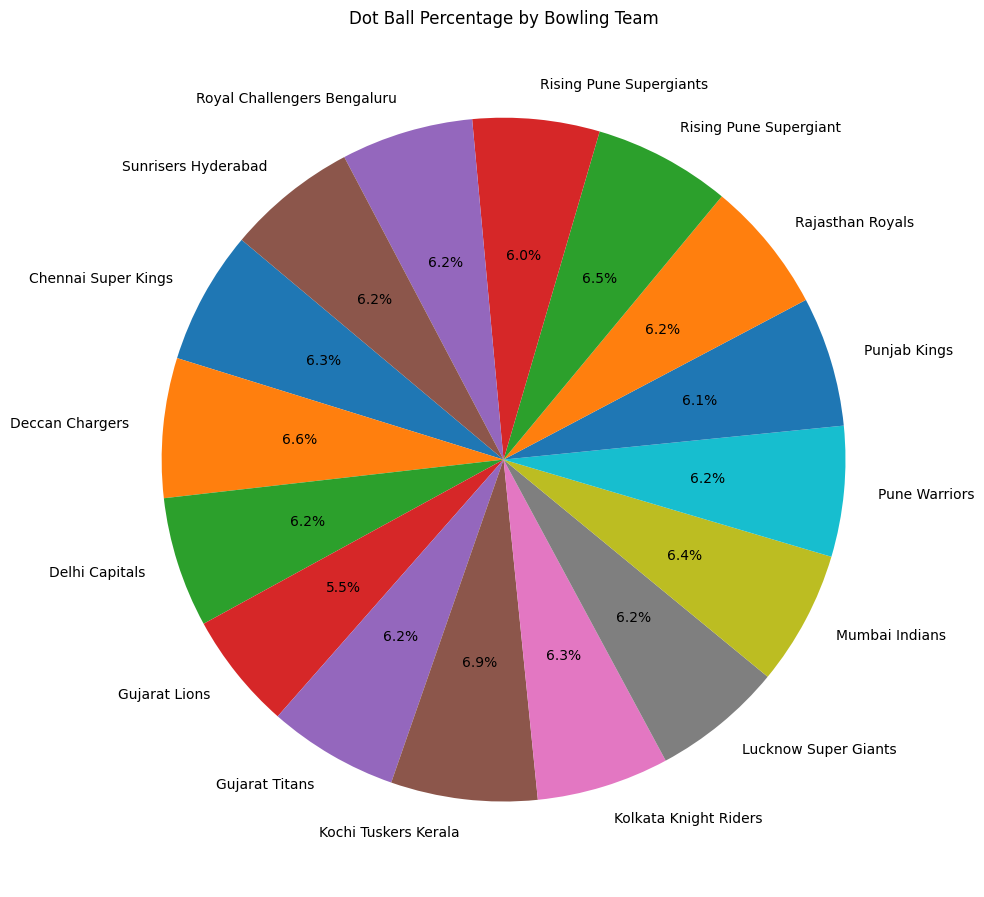

In [34]:

plt.figure(figsize=(10,10))

plt.pie(dot_ball['Dot_Ball_Percent'],
        labels=dot_ball.index,
        autopct='%1.1f%%',
        startangle=140)

plt.title("Dot Ball Percentage by Bowling Team")

plt.tight_layout()
plt.show()

In [ ]:
boundary_rows = df[df['is_boundary'] == 1]

team_boundaries = boundary_rows.groupby('batting_team')['is_boundary'].sum()

team_boundaries = team_boundaries.sort_values(ascending=False)

print(team_boundaries.head())

batting_team
Mumbai Indians                 5317
Royal Challengers Bengaluru    5025
Kolkata Knight Riders          4951
Punjab Kings                   4933
Delhi Capitals                 4855
Name: is_boundary, dtype: int64


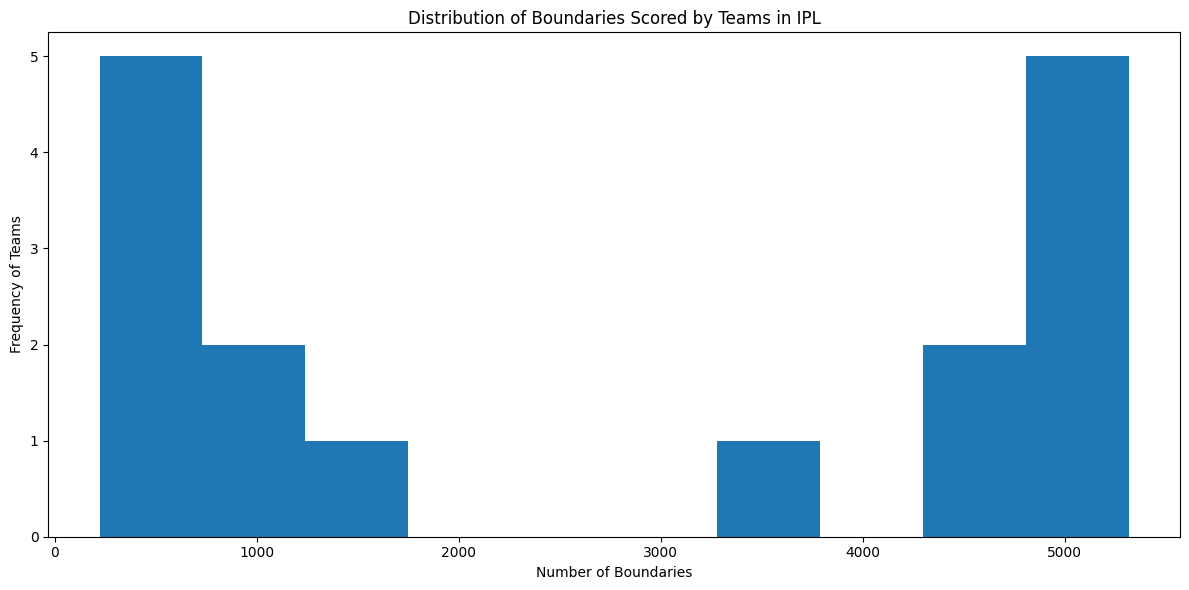

In [ ]:
plt.figure(figsize=(12,6))

plt.hist(team_boundaries.values, bins=10)
plt.title("Distribution of Boundaries Scored by Teams in IPL")
plt.xlabel("Number of Boundaries")
plt.ylabel("Frequency of Teams")

plt.tight_layout()
plt.show()